<div align="center">
  <img src="NNS_01.png" style="width:50%; border-radius:10px;">
</div>

## 1. 单神经元模型

我们先只考虑**一个输入特征** \(x\)，这样更容易画出参数 \(w,b\) 的损失曲面。

单神经元先做线性变换：

**公式 (1)**  
$$
z = wx + b
$$

然后经过 Sigmoid 激活函数：

**公式 (2)**  
$$
\hat y = \sigma(z) = \frac{1}{1+e^{-z}}
$$

所以整个模型就是：

**公式 (3)**  
$$
\hat y = \sigma(wx+b)
$$

其中：

- $ x $：输入
- $ w $：权重
- $ b $：偏置
- $ z $：线性部分输出
- $ \hat y $：预测值

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

## 2. 构造一个简单二分类数据集

为了方便演示，我们用一维输入：

- 小的 \(x\) 值对应类别 0
- 大的 \(x\) 值对应类别 1

这样就能直观看到 Sigmoid 神经元如何做分类。

In [2]:
# =========================
# Code block A: generate 1D dataset
# =========================
np.random.seed(42)

x = np.array([-2.5, -2.0, -1.5, -1.0, -0.5, 0.2, 0.8, 1.2, 1.8, 2.5], dtype=float)
y = np.array([0,    0,    0,    0,    0,   1,   1,   1,   1,   1], dtype=float)

n = len(x)

print("x =", x)
print("y =", y)
print("n =", n)

x = [-2.5 -2.  -1.5 -1.  -0.5  0.2  0.8  1.2  1.8  2.5]
y = [0. 0. 0. 0. 0. 1. 1. 1. 1. 1.]
n = 10


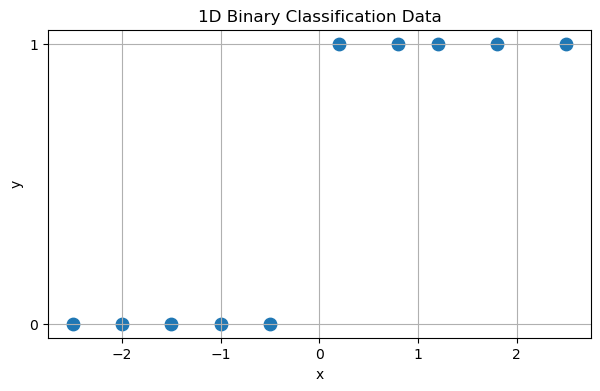

In [3]:
plt.figure(figsize=(7, 4))
plt.scatter(x, y, s=80)
plt.title("1D Binary Classification Data")
plt.xlabel("x")
plt.ylabel("y")
plt.yticks([0, 1])
plt.grid(True)
plt.show()

## 3. 前向传播公式与代码对应

### 3.1 激活函数

**公式 (2)**  
$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

### 3.2 预测公式

**公式 (3)**  
$$
\hat y = \sigma(wx+b)
$$

下面的代码里会明确标注公式编号。

In [4]:
# =========================
# Code block B: forward formulas
# =========================

def sigmoid(z):
    # 对应公式 (2)
    return 1 / (1 + np.exp(-z))

def predict(x, w, b):
    # 对应公式 (1): z = wx + b
    z = w * x + b

    # 对应公式 (3): y_hat = sigmoid(wx+b)
    y_hat = sigmoid(z)
    return y_hat

## 4. 损失函数

我们使用均方误差（MSE）来衡量预测和真实标签之间的差异。

**公式 (4)**  
$$
L(w,b) = \frac{1}{n}\sum_{i=1}^{n}\left(\hat y^{(i)} - y^{(i)}\right)^2
$$

把 **公式 (3)** 代入可得：

**公式 (5)**  
$$
L(w,b) = \frac{1}{n}\sum_{i=1}^{n}\left(\sigma(wx^{(i)}+b)-y^{(i)}\right)^2
$$

注意这里的损失 \(L\) 是 **参数 \(w,b\)** 的函数。  
也就是说，只要参数变了，整条预测曲线就会变，损失值也会变。

In [5]:
# =========================
# Code block C: loss function
# =========================

def mse_loss(x, y, w, b):
    # 先用公式 (3) 得到预测值
    y_hat = predict(x, w, b)

    # 对应公式 (4) / 公式 (5)
    loss = np.mean((y_hat - y) ** 2)
    return loss

## 5. 梯度推导：

先看单个样本的损失：

**公式 (6)**  
$$
\ell = (\hat y - y)^2
$$

由链式法则：

**公式 (7)**  
$$
\frac{\partial \ell}{\partial w}
=
\frac{\partial \ell}{\partial \hat y}
\cdot
\frac{\partial \hat y}{\partial z}
\cdot
\frac{\partial z}{\partial w}
$$

其中：

**公式 (8)**  
$$
\frac{\partial \ell}{\partial \hat y} = 2(\hat y-y)
$$

**公式 (9)**  
$$
\frac{\partial \hat y}{\partial z} = \hat y(1-\hat y)
$$

**公式 (10)**  
$$
\frac{\partial z}{\partial w} = x
$$

所以：

**公式 (11)**  
$$
\frac{\partial \ell}{\partial w}
=
2(\hat y-y)\hat y(1-\hat y)x
$$

同理：

**公式 (12)**  
$$
\frac{\partial z}{\partial b}=1
$$

因此：

**公式 (13)**  
$$
\frac{\partial \ell}{\partial b}
=
2(\hat y-y)\hat y(1-\hat y)
$$

对于整个数据集，取平均后得到：

**公式 (14)**  
$$
\frac{\partial L}{\partial w}
=
\frac{1}{n}\sum_{i=1}^{n}
2(\hat y^{(i)}-y^{(i)})\hat y^{(i)}(1-\hat y^{(i)})x^{(i)}
$$

**公式 (15)**  
$$
\frac{\partial L}{\partial b}
=
\frac{1}{n}\sum_{i=1}^{n}
2(\hat y^{(i)}-y^{(i)})\hat y^{(i)}(1-\hat y^{(i)})
$$

In [6]:
# =========================
# Code block D: gradients
# =========================

def gradients(x, y, w, b):
    # 对应公式 (1)
    z = w * x + b

    # 对应公式 (2)(3)
    y_hat = sigmoid(z)

    # 对应公式 (8): dℓ/dŷ = 2(ŷ-y)
    dloss_dyhat = 2 * (y_hat - y)

    # 对应公式 (9): dŷ/dz = ŷ(1-ŷ)
    dyhat_dz = y_hat * (1 - y_hat)

    # 对应公式 (14): dL/dw
    dw = np.mean(dloss_dyhat * dyhat_dz * x)

    # 对应公式 (15): dL/db
    db = np.mean(dloss_dyhat * dyhat_dz)

    return dw, db

## 6. 梯度下降更新公式

有了梯度之后，就能用梯度下降更新参数。

**公式 (16)**  
$$
w \leftarrow w - \eta \frac{\partial L}{\partial w}
$$

**公式 (17)**  
$$
b \leftarrow b - \eta \frac{\partial L}{\partial b}
$$

其中：

- $ \eta $：学习率（learning rate）
- 梯度指示损失增大的方向
- 减号表示我们朝着损失减小的方向走

In [7]:
# =========================
# Code block E: gradient descent training
# =========================

def train_gradient_descent(x, y, w0, b0, lr=1.0, epochs=80):
    w, b = w0, b0

    w_history = [w]
    b_history = [b]
    loss_history = [mse_loss(x, y, w, b)]

    for _ in range(epochs):
        dw, db = gradients(x, y, w, b)

        # 对应公式 (16)
        w = w - lr * dw

        # 对应公式 (17)
        b = b - lr * db

        w_history.append(w)
        b_history.append(b)
        loss_history.append(mse_loss(x, y, w, b))

    return np.array(w_history), np.array(b_history), np.array(loss_history)

## 7. 运行训练

In [8]:
# 初始参数
w0, b0 = -0.5, 0.0

# 训练
w_hist, b_hist, loss_hist = train_gradient_descent(x, y, w0, b0, lr=1.5, epochs=80)

print(f"Initial: w = {w_hist[0]:.4f}, b = {b_hist[0]:.4f}, loss = {loss_hist[0]:.6f}")
print(f"Final:   w = {w_hist[-1]:.4f}, b = {b_hist[-1]:.4f}, loss = {loss_hist[-1]:.6f}")

Initial: w = -0.5000, b = 0.0000, loss = 0.446397
Final:   w = 2.9804, b = 0.3768, loss = 0.014530


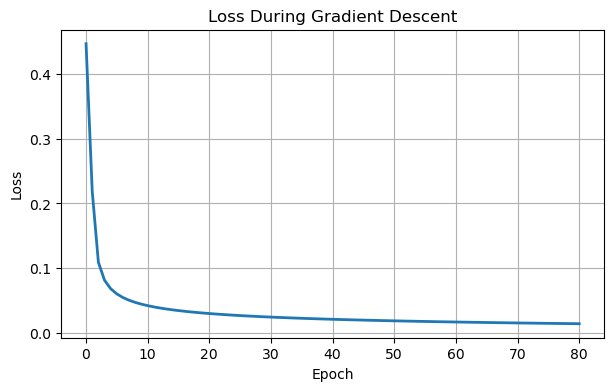

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(loss_hist, linewidth=2)
plt.title("Loss During Gradient Descent")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

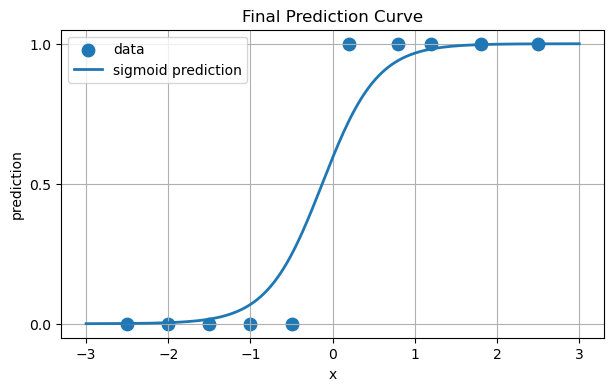

In [10]:
# 画最终预测曲线
x_plot = np.linspace(x.min() - 0.5, x.max() + 0.5, 300)
y_plot = predict(x_plot, w_hist[-1], b_hist[-1])

plt.figure(figsize=(7, 4))
plt.scatter(x, y, s=80, label="data")
plt.plot(x_plot, y_plot, linewidth=2, label="sigmoid prediction")
plt.title("Final Prediction Curve")
plt.xlabel("x")
plt.ylabel("prediction")
plt.yticks([0, 0.5, 1.0])
plt.legend()
plt.grid(True)
plt.show()

## 8. 画出损失函数 $L(w,b)$ 的 3D 图

这部分是本 Notebook 的重点。

根据 **公式 (5)**：

$$
L(w,b) = \frac{1}{n}\sum_{i=1}^{n}\left(\sigma(wx^{(i)}+b)-y^{(i)}\right)^2
$$

我们可以：

1. 在很多不同的 $ w $ 值上取点
2. 在很多不同的 $ b $ 值上取点
3. 对每一组 $ w,b $ 计算一次损失 $ L(w,b) $

这样就能得到一个曲面：

- 横轴：$ w $
- 纵轴：$ b $
- 高度：损失值 $ L(w,b) $

这个 3D 曲面就告诉我们：  
**参数在什么位置时损失高，什么位置时损失低。**

In [11]:
# =========================
# Code block F: build loss surface L(w,b)
# =========================

w_vals = np.linspace(-4.0, 4.0, 140)
b_vals = np.linspace(-4.0, 4.0, 140)
W, B = np.meshgrid(w_vals, b_vals)

L = np.zeros_like(W)

# 对每一组 (w,b) 计算公式 (5)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        L[i, j] = mse_loss(x, y, W[i, j], B[i, j])

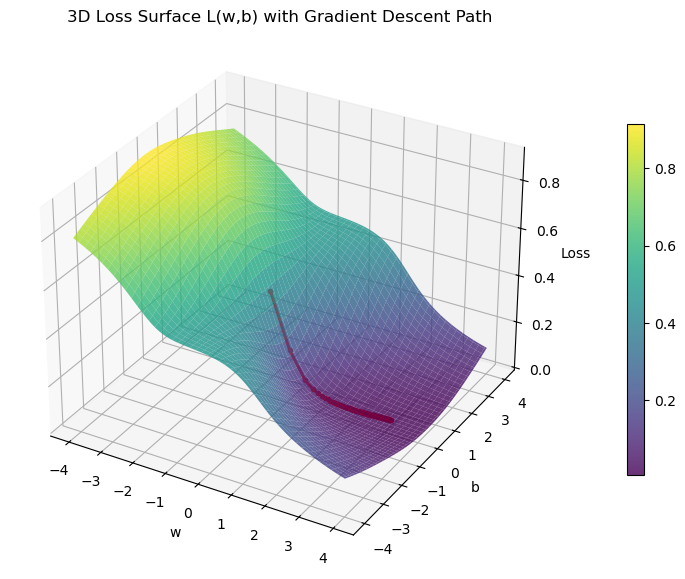

In [12]:
# 3D loss surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(W, B, L, cmap="viridis", alpha=0.80, edgecolor="none")

# 梯度下降路径
ax.plot(w_hist, b_hist, loss_hist, color="red", marker="o", markersize=3, linewidth=2.2)

ax.set_title("3D Loss Surface L(w,b) with Gradient Descent Path")
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("Loss")
fig.colorbar(surf, ax=ax, shrink=0.65, pad=0.1)
plt.show()

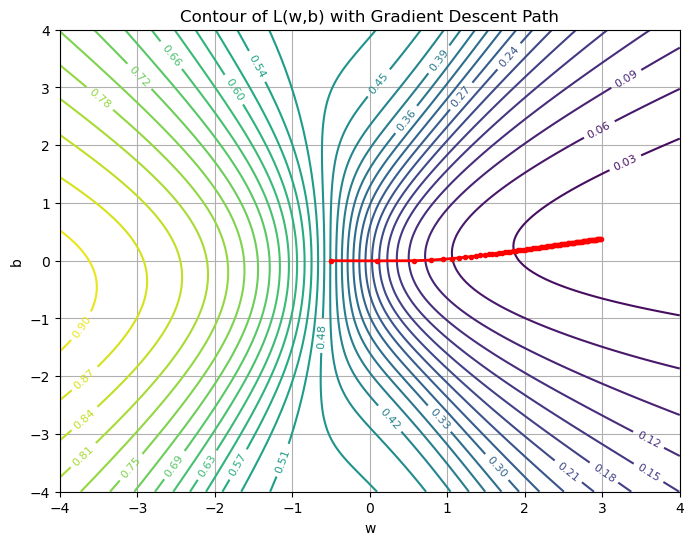

In [13]:
# 2D contour of loss surface
plt.figure(figsize=(8, 6))
contour = plt.contour(W, B, L, levels=30, cmap="viridis")
plt.clabel(contour, inline=True, fontsize=8)
plt.plot(w_hist, b_hist, color="red", marker="o", markersize=3, linewidth=2)
plt.title("Contour of L(w,b) with Gradient Descent Path")
plt.xlabel("w")
plt.ylabel("b")
plt.grid(True)
plt.show()